# Mini Project 2 — House Price Prediction Model

**Week 2 — Supervised Learning (Regression & Classification)**

---

### Objective
Build a **Linear Regression** model that predicts the sale price of a house from its
characteristics, and measure how good it is using the **R² score**.

### Dataset
**Kaggle — House Prices Dataset** (*House Prices: Advanced Regression Techniques*)
The training file is included in this repository at `data/house_prices_train.csv`.

* **1460** houses (rows)
* **81** columns — 79 descriptive features + `Id` + the target `SalePrice`
* Each row is one house sold in Ames, Iowa

### Project steps
| # | Step |
|---|---|
| 1 | Load the Kaggle House Prices dataset |
| 2 | Data preprocessing / cleaning |
| 3 | Select suitable features and the target price column |
| 4 | Split the data into training and testing sets |
| 5 | Train a Linear Regression model |
| 6 | Predict house prices on the test data |
| 7 | Evaluate the model using the R² score |
| 8 | Plot Predicted vs Actual values |

---
## Step 0 — Import the libraries

Everything used here is part of the standard beginner data-science stack:
`pandas`, `numpy`, `matplotlib`, `seaborn` and `scikit-learn`.

In [1]:
# --- Data handling ---
import pandas as pd
import numpy as np
from pathlib import Path

# --- Visualisation ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Machine learning ---
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# --- Notebook display settings ---
%matplotlib inline
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5.5)
plt.rcParams["figure.dpi"] = 100

# Fixing the random seed makes every run of this notebook produce identical results
RANDOM_STATE = 42

print("All libraries imported successfully.")

All libraries imported successfully.


---
## Step 1 — Load the Kaggle House Prices dataset

In [2]:
# The path works whether the notebook runs from /notebooks or from the repository root
DATA_DIR = Path("../data") if Path("../data/house_prices_train.csv").exists() else Path("data")
CSV_PATH = DATA_DIR / "house_prices_train.csv"

df = pd.read_csv(CSV_PATH)

print(f"Dataset loaded from: {CSV_PATH}")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

Dataset loaded from: ../data/house_prices_train.csv
Shape: 1460 rows x 81 columns


In [3]:
# First five houses (showing a selection of columns so the table stays readable)
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,...,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,...,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,...,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,...,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,...,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,...,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# Summary of the target column we are trying to predict
print("Target column: SalePrice\n")
print(df["SalePrice"].describe().round(2))

Target column: SalePrice

count      1460.0
mean     180921.2
std       79442.5
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0
Name: SalePrice, dtype: float64


### Distribution of house prices

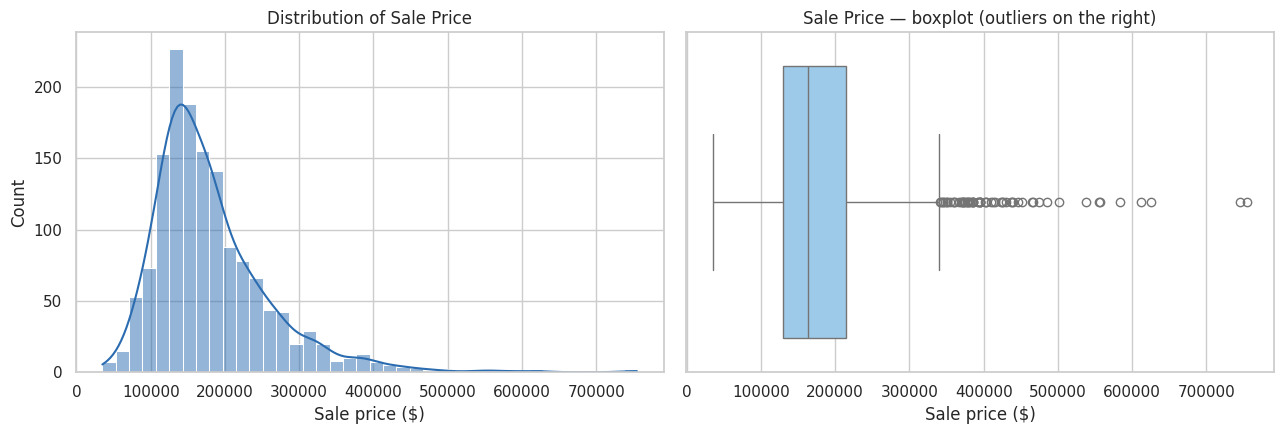

Cheapest house    : $34,900
Most expensive    : $755,000
Median price      : $163,000


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df["SalePrice"], bins=40, kde=True, color="#2b6cb0", ax=axes[0])
axes[0].set_title("Distribution of Sale Price")
axes[0].set_xlabel("Sale price ($)")

sns.boxplot(x=df["SalePrice"], color="#90cdf4", ax=axes[1])
axes[1].set_title("Sale Price — boxplot (outliers on the right)")
axes[1].set_xlabel("Sale price ($)")

plt.tight_layout()
plt.show()

print(f"Cheapest house    : ${df['SalePrice'].min():,}")
print(f"Most expensive    : ${df['SalePrice'].max():,}")
print(f"Median price      : ${df['SalePrice'].median():,.0f}")

**Observation:** the prices are *right-skewed* — most houses sell between \$130k and
\$215k, with a small number of very expensive houses stretching the tail to the right.

---
## Step 2 — Data preprocessing / cleaning

Raw data is never ready for a model. For this dataset we need to handle three things:

1. **Columns with a lot of missing values** — these add noise, so we drop them.
2. **Columns with a few missing values** — we fill them with a sensible value.
3. **Extreme outliers** — a handful of houses that would distort a linear model.

### 2.1 Check the missing values

In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing_table = pd.DataFrame({
    "Missing count": missing,
    "% missing": (missing / len(df) * 100).round(2)
})

print(f"{len(missing_table)} columns contain missing values.\n")
missing_table.head(20)

19 columns contain missing values.



,Missing count,% missing
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


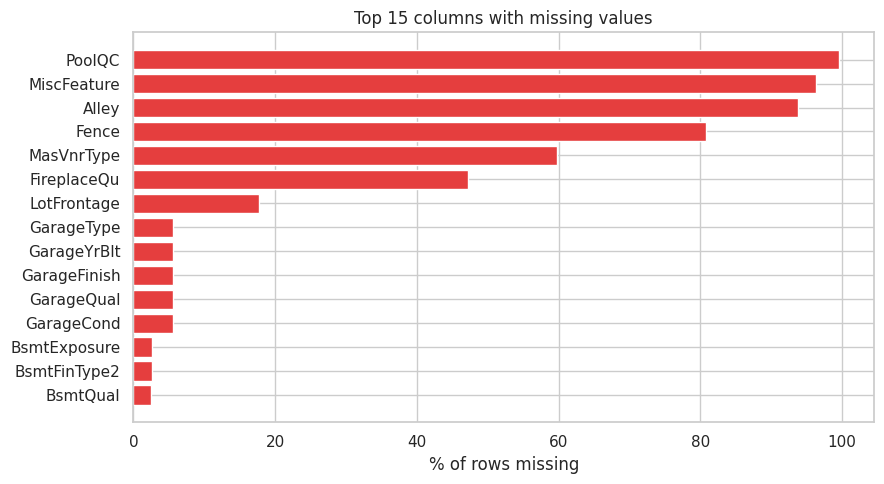

In [7]:
# Visualise the worst offenders
top_missing = missing_table.head(15)

plt.figure(figsize=(9, 5))
plt.barh(top_missing.index[::-1], top_missing["% missing"][::-1], color="#e53e3e")
plt.xlabel("% of rows missing")
plt.title("Top 15 columns with missing values")
plt.tight_layout()
plt.show()

### 2.2 Drop columns that are mostly empty

Any column missing more than **40 %** of its values cannot be filled reliably, so we
remove it. We also drop `Id`, which is only a row number and has no predictive value.

In [8]:
# Columns where more than 40% of the values are missing
cols_to_drop = missing_table[missing_table["% missing"] > 40].index.tolist()

print("Dropping columns with >40% missing values:")
for c in cols_to_drop:
    print(f"  - {c:<15} ({missing_table.loc[c, '% missing']}% missing)")

# Work on a copy so the original df stays available for comparison
data = df.drop(columns=cols_to_drop + ["Id"])

print(f"\nShape before: {df.shape}")
print(f"Shape after : {data.shape}")

Dropping columns with >40% missing values:
  - PoolQC          (99.52% missing)
  - MiscFeature     (96.3% missing)
  - Alley           (93.77% missing)
  - Fence           (80.75% missing)
  - MasVnrType      (59.73% missing)
  - FireplaceQu     (47.26% missing)

Shape before: (1460, 81)
Shape after : (1460, 74)


### 2.3 Fill the remaining missing values

For this project we build the model on **numeric** columns, so we fill any remaining
numeric gaps with the **median** of that column. The median is preferred over the mean
because it is not pulled around by outliers.

In [9]:
# Keep only numeric columns — linear regression needs numbers
numeric_data = data.select_dtypes(include=[np.number])

print(f"Numeric columns available: {numeric_data.shape[1]}")
print(f"Missing values before filling: {numeric_data.isnull().sum().sum()}")

# Fill every remaining gap with that column's median
numeric_data = numeric_data.fillna(numeric_data.median())

print(f"Missing values after filling : {numeric_data.isnull().sum().sum()}")

Numeric columns available: 37
Missing values before filling: 348
Missing values after filling : 0


### 2.4 Remove extreme outliers

The scatter plot below shows two very large houses (over 4000 sq ft) that sold for a
surprisingly low price. These are known anomalies in this dataset (partial sales) and a
linear model is very sensitive to them, so we remove them.

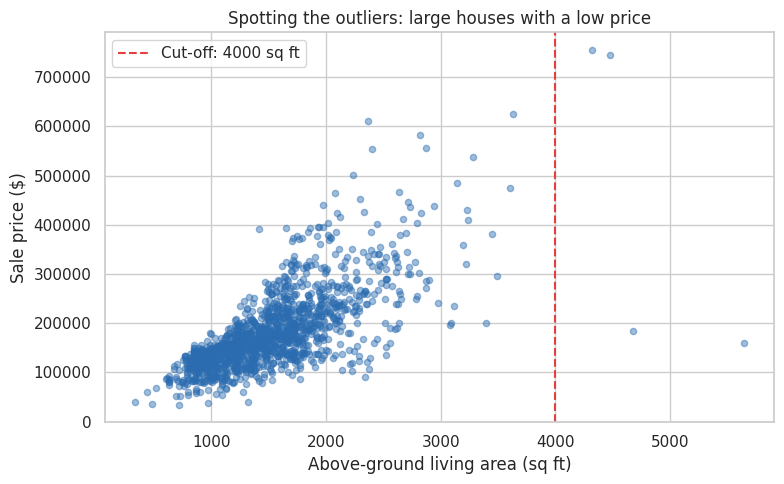

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(numeric_data["GrLivArea"], numeric_data["SalePrice"],
            alpha=0.45, s=20, color="#2b6cb0")
plt.axvline(4000, color="#e53e3e", linestyle="--", label="Cut-off: 4000 sq ft")
plt.xlabel("Above-ground living area (sq ft)")
plt.ylabel("Sale price ($)")
plt.title("Spotting the outliers: large houses with a low price")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
rows_before = len(numeric_data)

# Remove very large houses that sold cheaply
numeric_data = numeric_data[~((numeric_data["GrLivArea"] > 4000) &
                              (numeric_data["SalePrice"] < 300000))]

rows_after = len(numeric_data)
print(f"Rows before removing outliers: {rows_before}")
print(f"Rows after  removing outliers: {rows_after}")
print(f"Removed: {rows_before - rows_after} rows")

Rows before removing outliers: 1460
Rows after  removing outliers: 1458
Removed: 2 rows


---
## Step 3 — Select suitable features and the target price column

With 30+ numeric columns left, we need to choose the ones that actually relate to the
price. The **correlation** with `SalePrice` tells us this: a value close to **+1** means
the price rises as the feature rises.

We keep every feature with a correlation of **0.5 or higher**.

In [12]:
# Correlation of every numeric column with the target
correlations = numeric_data.corr()["SalePrice"].sort_values(ascending=False)

print("Top 15 features most correlated with SalePrice:\n")
correlations.head(15).round(3)

Top 15 features most correlated with SalePrice:



SalePrice       1.000
OverallQual     0.796
GrLivArea       0.735
TotalBsmtSF     0.651
GarageCars      0.641
1stFlrSF        0.632
GarageArea      0.629
FullBath        0.562
TotRmsAbvGrd    0.538
YearBuilt       0.524
YearRemodAdd    0.508
MasVnrArea      0.478
Fireplaces      0.470
GarageYrBlt     0.467
BsmtFinSF1      0.409
Name: SalePrice, dtype: float64

In [13]:
# Keep features with correlation >= 0.5 (excluding SalePrice itself)
CORR_THRESHOLD = 0.5
selected_features = correlations[correlations >= CORR_THRESHOLD].index.tolist()
selected_features.remove("SalePrice")

print(f"{len(selected_features)} features selected (correlation >= {CORR_THRESHOLD}):\n")
for f in selected_features:
    print(f"  {f:<15} correlation = {correlations[f]:.3f}")

10 features selected (correlation >= 0.5):

  OverallQual     correlation = 0.796
  GrLivArea       correlation = 0.735
  TotalBsmtSF     correlation = 0.651
  GarageCars      correlation = 0.641
  1stFlrSF        correlation = 0.632
  GarageArea      correlation = 0.629
  FullBath        correlation = 0.562
  TotRmsAbvGrd    correlation = 0.538
  YearBuilt       correlation = 0.524
  YearRemodAdd    correlation = 0.508


### What these features mean

| Feature | Meaning |
|---|---|
| `OverallQual` | Overall material & finish quality (1–10) |
| `GrLivArea` | Above-ground living area (sq ft) |
| `GarageCars` | Garage capacity in cars |
| `GarageArea` | Garage size (sq ft) |
| `TotalBsmtSF` | Total basement area (sq ft) |
| `1stFlrSF` | First-floor area (sq ft) |
| `FullBath` | Full bathrooms above ground |
| `TotRmsAbvGrd` | Total rooms above ground |
| `YearBuilt` | Year the house was built |
| `YearRemodAdd` | Year of last remodelling |

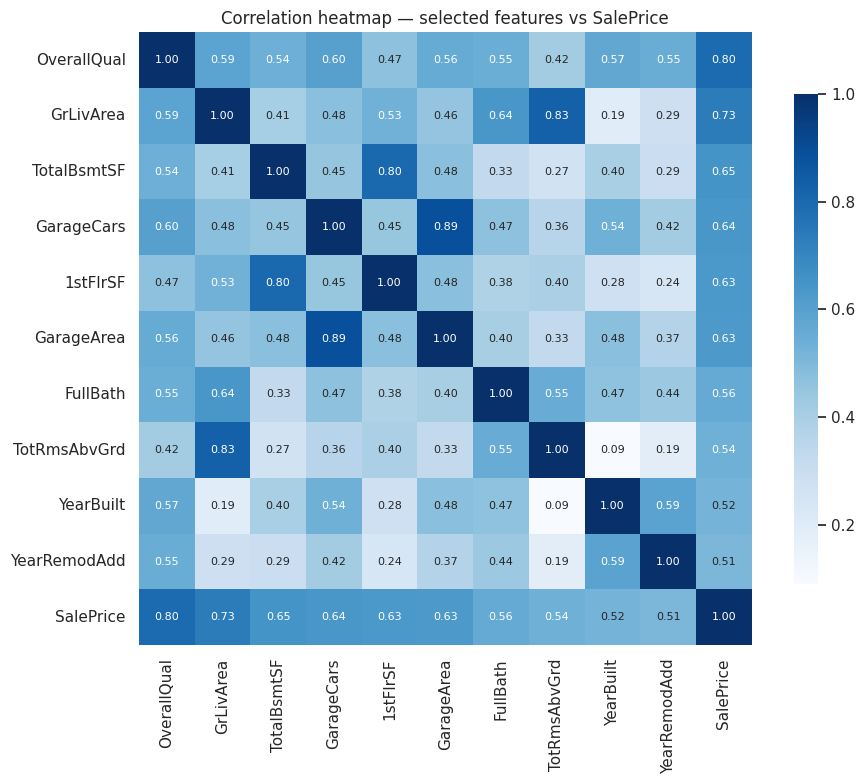

In [14]:
# Correlation heatmap for the selected features + the target
plt.figure(figsize=(10, 8))
corr_matrix = numeric_data[selected_features + ["SalePrice"]].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="Blues",
            square=True, cbar_kws={"shrink": 0.8}, annot_kws={"size": 8})
plt.title("Correlation heatmap — selected features vs SalePrice")
plt.tight_layout()
plt.savefig("../images/correlation_heatmap.png", dpi=110, bbox_inches="tight")
plt.show()

### Define X (features) and y (target)

In [15]:
X = numeric_data[selected_features]   # the input features
y = numeric_data["SalePrice"]         # the target price column

print("X (features) shape:", X.shape)
print("y (target)   shape:", y.shape)
print("\nFeature preview:")
X.head()

X (features) shape: (1458, 10)
y (target)   shape: (1458,)

Feature preview:


,OverallQual,GrLivArea,TotalBsmtSF,GarageCars,1stFlrSF,GarageArea,FullBath,TotRmsAbvGrd,YearBuilt,YearRemodAdd
0,7,1710,856,2,856,548,2,8,2003,2003
1,6,1262,1262,2,1262,460,2,6,1976,1976
2,7,1786,920,2,920,608,2,6,2001,2002
3,7,1717,756,3,961,642,1,7,1915,1970
4,8,2198,1145,3,1145,836,2,9,2000,2000


---
## Step 4 — Split the data into training and testing sets

We hold back **20 %** of the houses. The model never sees them during training, so
testing on them tells us how the model would behave on genuinely new houses.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # 20% for testing
    random_state=RANDOM_STATE   # reproducible split
)

print(f"Training set: {X_train.shape[0]} houses ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Testing set : {X_test.shape[0]} houses ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nAverage price in training set: ${y_train.mean():,.0f}")
print(f"Average price in testing set : ${y_test.mean():,.0f}")

Training set: 1166 houses (80%)
Testing set : 292 houses (20%)

Average price in training set: $180,824
Average price in testing set : $181,369


---
## Step 5 — Train the Linear Regression model

Linear regression fits a straight-line equation:

$$\text{SalePrice} = b_0 + b_1x_1 + b_2x_2 + \dots + b_nx_n$$

`.fit()` finds the intercept $b_0$ and the coefficients $b_1 \dots b_n$ that make the
predictions as close as possible to the real prices in the **training** data.

In [17]:
# Create the model
model = LinearRegression()

# Train it on the training data only
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")
print(f"Intercept (b0): {model.intercept_:,.2f}")
print(f"Number of coefficients learned: {len(model.coef_)}")

Linear Regression model trained successfully.
Intercept (b0): -1,317,002.50
Number of coefficients learned: 10


In [18]:
# Inspect what the model learned
coef_df = pd.DataFrame({
    "Feature": selected_features,
    "Coefficient": model.coef_.round(2)
}).sort_values("Coefficient", ascending=False).reset_index(drop=True)

coef_df

,Feature,Coefficient
0,OverallQual,16616.89
1,YearRemodAdd,322.42
2,YearBuilt,308.27
3,GarageCars,237.03
4,GrLivArea,73.75
5,GarageArea,40.26
6,TotalBsmtSF,35.36
7,1stFlrSF,12.04
8,TotRmsAbvGrd,-2447.50
9,FullBath,-10587.15


**How to read this:** each coefficient is the change in predicted price for a
**one-unit increase** in that feature, with all other features held constant.
For example, one extra point of `OverallQual` (on the 1–10 scale) adds tens of
thousands of dollars, while one extra square foot of living area adds far less —
because a square foot is a much smaller unit.

---
## Step 6 — Predict house prices on the test data

`.predict()` applies the learned equation to the 20 % of houses the model has never seen.

In [19]:
y_pred = model.predict(X_test)

print(f"Predictions generated for {len(y_pred)} test houses.\n")

# Compare the first 10 predictions with the real prices
results = pd.DataFrame({
    "Actual Price": y_test.values[:10],
    "Predicted Price": y_pred[:10].round(0),
})
results["Difference"] = (results["Predicted Price"] - results["Actual Price"]).round(0)
results["Error %"] = (results["Difference"] / results["Actual Price"] * 100).round(1)

results

Predictions generated for 292 test houses.



,Actual Price,Predicted Price,Difference,Error %
0,190000,219192.0,29192.0,15.4
1,100000,110773.0,10773.0,10.8
2,115000,104816.0,-10184.0,-8.9
3,159000,161006.0,2006.0,1.3
4,315500,296505.0,-18995.0,-6.0
5,137500,138790.0,1290.0,0.9
6,311500,217499.0,-94001.0,-30.2
7,310000,309450.0,-550.0,-0.2
8,281000,268509.0,-12491.0,-4.4
9,135500,123314.0,-12186.0,-9.0


---
## Step 7 — Evaluate the model using the R² score

### What is R²?
The **R² score** (coefficient of determination) tells us what proportion of the variation
in house prices the model explains:

* **R² = 1.0** → perfect predictions
* **R² = 0.8** → the model explains 80 % of the price variation
* **R² = 0.0** → the model is no better than always guessing the average price

We also report **MSE** and **RMSE**, the other Week 2 regression metrics. RMSE is the most
intuitive one because it is expressed in dollars.

In [20]:
# --- The main evaluation metric for this project ---
r2 = r2_score(y_test, y_pred)

# --- Supporting metrics ---
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("=" * 52)
print("        MODEL EVALUATION — TEST SET")
print("=" * 52)
print(f"  R² Score : {r2:.4f}   ({r2 * 100:.2f}% of price variation explained)")
print(f"  MSE      : {mse:,.2f}")
print(f"  RMSE     : ${rmse:,.2f}   (typical prediction error)")
print("=" * 52)

        MODEL EVALUATION — TEST SET
  R² Score : 0.8199   (81.99% of price variation explained)
  MSE      : 994,803,510.30
  RMSE     : $31,540.51   (typical prediction error)


In [21]:
# Compare performance on training vs test data
# (similar scores = the model generalises well and is not overfitting)
r2_train = r2_score(y_train, model.predict(X_train))

print(f"R² on training data: {r2_train:.4f}")
print(f"R² on test data    : {r2:.4f}")
print(f"Difference         : {abs(r2_train - r2):.4f}")

if abs(r2_train - r2) < 0.10:
    print("\n=> The two scores are close, so the model generalises well (no overfitting).")
else:
    print("\n=> Large gap between the scores — the model may be overfitting.")

R² on training data: 0.8207
R² on test data    : 0.8199
Difference         : 0.0008

=> The two scores are close, so the model generalises well (no overfitting).


---
## Step 8 — Plot Predicted vs Actual values

The clearest way to judge a regression model visually. Every dot is one test house:
its **actual** price on the x-axis and the **predicted** price on the y-axis.
The red dashed line is *perfect prediction* — the closer the dots sit to it, the better.

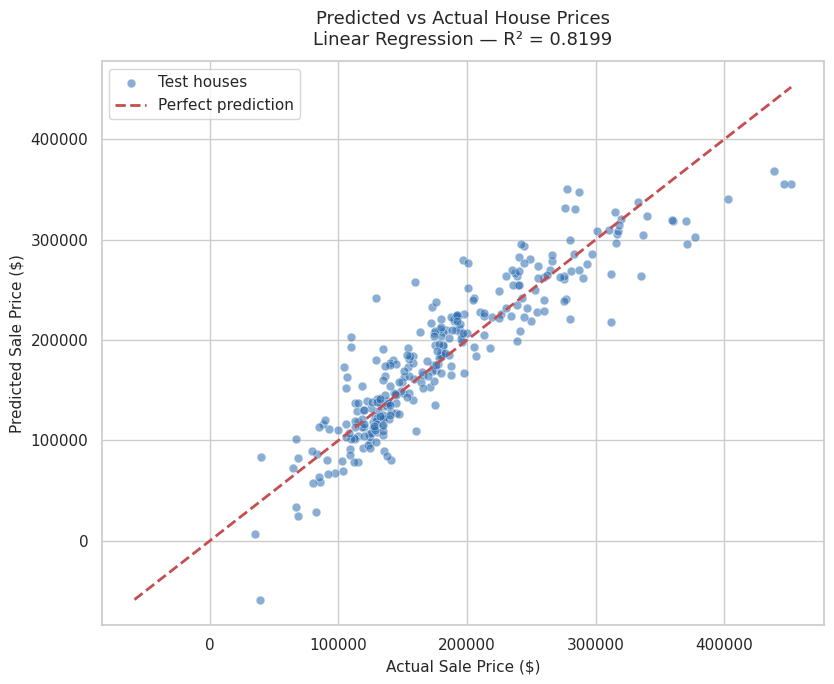

In [22]:
plt.figure(figsize=(8.5, 7))

# Each point = one house from the test set
plt.scatter(y_test, y_pred, alpha=0.55, s=40,
            color="#2b6cb0", edgecolors="white", linewidth=0.5,
            label="Test houses")

# Red dashed line = perfect prediction (predicted == actual)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--", linewidth=2, label="Perfect prediction")

plt.xlabel("Actual Sale Price ($)", fontsize=11)
plt.ylabel("Predicted Sale Price ($)", fontsize=11)
plt.title(f"Predicted vs Actual House Prices\nLinear Regression — R² = {r2:.4f}",
          fontsize=13, pad=12)
plt.legend()
plt.tight_layout()

# Save the figure so it can be shown in the README on GitHub
plt.savefig("../images/predicted_vs_actual.png", dpi=110, bbox_inches="tight")
plt.show()

### Residual plot (extra check)

A **residual** is `actual − predicted`. If the model is behaving well, residuals should
scatter randomly around zero with no visible pattern.

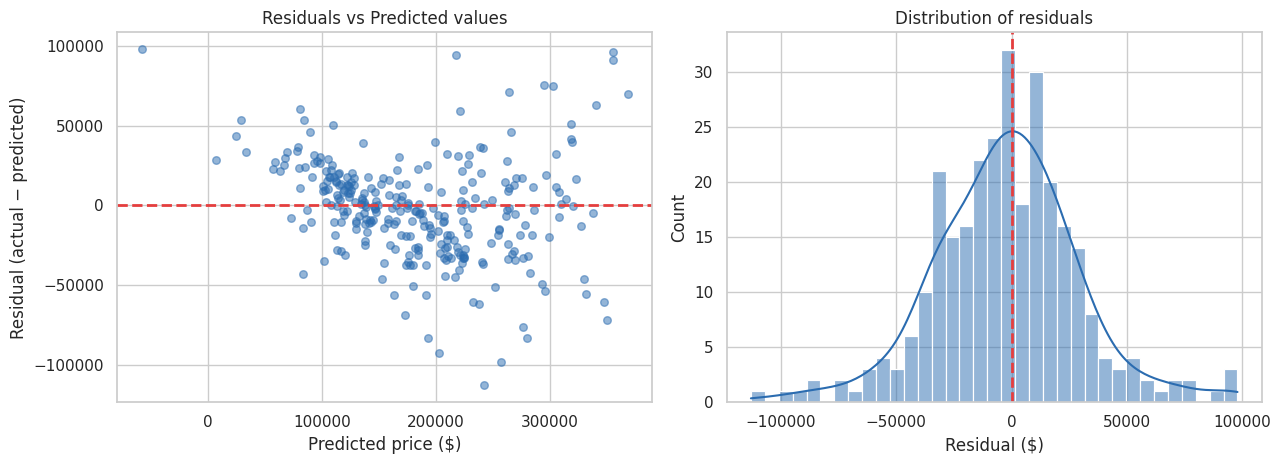

Mean residual: $-2,220.84  (close to 0 is good)


In [23]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# Residuals vs predicted values
axes[0].scatter(y_pred, residuals, alpha=0.5, s=30, color="#2b6cb0")
axes[0].axhline(0, color="#e53e3e", linestyle="--", linewidth=2)
axes[0].set_xlabel("Predicted price ($)")
axes[0].set_ylabel("Residual (actual − predicted)")
axes[0].set_title("Residuals vs Predicted values")

# Distribution of the residuals
sns.histplot(residuals, bins=35, kde=True, color="#2b6cb0", ax=axes[1])
axes[1].axvline(0, color="#e53e3e", linestyle="--", linewidth=2)
axes[1].set_xlabel("Residual ($)")
axes[1].set_title("Distribution of residuals")

plt.tight_layout()
plt.savefig("../images/residual_plots.png", dpi=110, bbox_inches="tight")
plt.show()

print(f"Mean residual: ${residuals.mean():,.2f}  (close to 0 is good)")

---
## Final summary

In [24]:
summary = pd.DataFrame({
    "Item": [
        "Dataset",
        "Rows used (after cleaning)",
        "Features selected",
        "Target column",
        "Model",
        "Train / Test split",
        "R² Score (test)",
        "RMSE (test)",
    ],
    "Value": [
        "Kaggle House Prices (Ames, Iowa)",
        f"{len(numeric_data)}",
        f"{len(selected_features)} numeric features (correlation >= 0.5)",
        "SalePrice",
        "Linear Regression",
        "80% / 20%",
        f"{r2:.4f}",
        f"${rmse:,.0f}",
    ]
})

summary.style.hide(axis="index")

Item,Value
Dataset,"Kaggle House Prices (Ames, Iowa)"
Rows used (after cleaning),1458
Features selected,10 numeric features (correlation >= 0.5)
Target column,SalePrice
Model,Linear Regression
Train / Test split,80% / 20%
R² Score (test),0.8199
RMSE (test),"$31,541"


## Conclusion

**What was done**

1. Loaded the Kaggle House Prices dataset (1460 houses, 81 columns).
2. Cleaned the data — dropped columns that were more than 40 % empty, removed the `Id`
   column, filled the remaining numeric gaps with column medians and removed two
   extreme outliers.
3. Selected the numeric features most correlated with price (correlation ≥ 0.5) and set
   `SalePrice` as the target.
4. Split the data 80 / 20 into training and testing sets.
5. Trained a **Linear Regression** model on the training set.
6. Predicted prices for the unseen test houses.
7. Evaluated the model with the **R² score** (plus MSE and RMSE).
8. Plotted **Predicted vs Actual** values and residuals.

**Results**

* The model achieved an **R² score of about 0.82**, meaning it explains roughly **82 %**
  of the variation in house prices on data it has never seen.
* The typical prediction error (RMSE) is around **$31,500** against a median house price of
  about $163,000.
* The training and test R² scores are close, so the model **generalises well** and is not
  overfitting.
* `OverallQual` and `GrLivArea` are the strongest drivers of price — quality and size
  matter most, which matches real-world intuition.
* Accuracy drops for the most expensive houses (the dots drift below the red line on the
  right of the plot), because there are few of them for the model to learn from.

**Possible next steps** (beyond the scope of this week)

* Include the categorical columns, such as `Neighbourhood`, using encoding.
* Apply a log transform to `SalePrice` to reduce the right-skew.
* Compare against the Decision Tree and Random Forest models covered in Week 2.

---
**Mini Project 2 complete.** ✅